# Libreta de KMEANS y PCA

En los siguientes bloques de codigo se trabajara el analisis de clusters,

## Se imporrtan las librerias necesarias para el analisis

- Polars 
- Mathplotlib
- Numpy
- skleran: Clusters
- Bokeh: models, plotting, palettes


In [ ]:
# Librerías básicas
import numpy as np
import polars as pl

# Visualización
import matplotlib.pyplot as plt
from bokeh.plotting import figure, show, output_file
from bokeh.models import ColumnDataSource, HoverTool
from bokeh.palettes import Category10
from bokeh.models import HoverTool
from bokeh.io import show

# Preprocesamiento y Outliers
from sklearn.preprocessing import RobustScaler, QuantileTransformer
from sklearn.neighbors import LocalOutlierFactor

# Reducción de Dimensionalidad
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Clustering y Métricas
from sklearn_extra.cluster import KMedoids

# Lectura del excel

Se da la ruta del excel las hojas y las categorias y las columnas a graficas, así como la lectura de datos

In [9]:
# Ruta a tu Excel
ruta_excel = "C Manufacturing.xlsx"
excel_hojas = ["Sheet1"] # Lista de hojas a cargar (puedes agregar más si quieres comparar varias)
Categorias = ["Acidification: terrestrial",  "Climate change",  "Ecotoxicity: freshwater",  "Ecotoxicity: marine",  "Ecotoxicity: terrestrial",
    "Energy resources: non-renewable, fossil",  "Eutrophication: freshwater",  "Eutrophication: marine",  "Human toxicity: carcinogenic",
    "Human toxicity: non-carcinogenic",  "Ionising radiation", "Land use",  "Material resources: metals/minerals",  "Ozone depletion",
    "Particulate matter formation", "Photochemical oxidant formation: human health", "Photochemical oxidant formation: terrestrial ecosystems",
    "Water use" ]

# Columnas de impacto que quieres graficar
hojas = [excel_hojas[0]]
#impacto_x = Categorias[12]
#impacto_y = Categorias[13]

In [10]:
# Leer solo la primera hoja
df = pl.read_excel(ruta_excel, sheet_name=excel_hojas[0])

# Convertir TODAS las columnas de impacto a numéricas (forzar errores a null)
# Creamos una lista de instrucciones para Polars, iterando sobre tus 18 categorías
instrucciones_cast = [
    pl.col(cat).cast(pl.Float64, strict=False).alias(cat) 
    for cat in Categorias
]
df = df.with_columns(instrucciones_cast)

# Filtrar filas válidas
# En lugar de usar '&' 18 veces, drop_nulls elimina la fila si falta el dato en CUALQUIERA de las categorías
df_num = df.drop_nulls(subset=Categorias)

print(f"Materiales válidos: {len(df_num)}")

Materiales válidos: 8097


### Kmenas

Primero se convierten los valores de las columnas deseadas a listas para trabajar de manera más simple con la libreria y los datos a graficas, posterior se escoge el numero de clusters, se obtienen los centroiden y se ordenan en orden numerico. Tambien se agrega la columna de clusters para ayudar al filtrado

In [11]:
# Convertir a listas para referencias posteriores
materials = df_num["Name"].to_list()
ids = df_num["id"].to_list() 
ubi = df_num["ubi"].to_list()

print("1. Preparando matriz con las 18 categorías...")
# Usamos la lista 'Categorias' que definimos al principio, NO solo x y y
X_full = df_num.select(Categorias).to_numpy()

print("2. Normalizando datos...")
# Forzamos una distribución normal para evitar que los valores extremos rompan las distancias
scaler = QuantileTransformer(output_distribution='normal', random_state=42)
X_scaled = scaler.fit_transform(X_full)

print("3. Aplicando PCA para el clustering...")
# Reducimos dimensiones reteniendo el 95% de la información
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("4. Ejecutando K-Medoids...")
# Decidimos usar 5 clústeres (puedes cambiarlo a 2 si prefieres el pico máximo de la silueta)
kmedoids = KMedoids(n_clusters=5, random_state=42)
clusters = kmedoids.fit_predict(X_pca)

# REORDENAR CLÚSTERES 
# Ordenamos basándonos en la primera componente del PCA (suele indicar el impacto general)
centroids_pca = kmedoids.cluster_centers_
orden_pca = np.argsort(centroids_pca[:, 0])

nuevo_orden = {old: new for new, old in enumerate(orden_pca)}
clusters_ordenados = np.array([nuevo_orden[c] for c in clusters])

print("5. Calculando t-SNE para la visualización 2D (esto toma unos segundos)...")
# t-SNE proyectará tus 18 dimensiones a solo 2 coordenadas (X y Y) para poder dibujarlas
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled) 

# GUARDAR TODO EN POLARS
# Guardamos el cluster y las nuevas coordenadas 2D generadas por t-SNE
df_num = df_num.with_columns([
    pl.Series("cluster", clusters_ordenados),
    pl.Series("tsne_x", X_tsne[:, 0]),
    pl.Series("tsne_y", X_tsne[:, 1])
])

#  IDENTIFICAR LOS MATERIALES REPRESENTATIVOS 
indices_medoides = kmedoids.medoid_indices_
print("\nMateriales representativos (centros reales) de los clústeres:")
for idx in indices_medoides:
    # Mostramos el cluster reordenado para que coincida con tu tabla final
    cluster_num = nuevo_orden[clusters[idx]]
    print(f"- Clúster {cluster_num}: {materials[idx]} (ID: {ids[idx]})")

1. Preparando matriz con las 18 categorías...
2. Normalizando datos...
3. Aplicando PCA para el clustering...
4. Ejecutando K-Medoids...
5. Calculando t-SNE para la visualización 2D (esto toma unos segundos)...

Materiales representativos (centros reales) de los clústeres:
- Clúster 3: market for hydrazine | hydrazine | Cutoff, U (ID: 3f26a6ef-f424-39c8-951c-d03750474e2a)
- Clúster 1: market for extrusion of plastic sheets and thermoforming, inline | extrusion of plastic sheets and thermoforming, inline | Cutoff, U (ID: 41c3a515-3f5e-33ec-af72-b87a9e5f6bd1)
- Clúster 0: market for heavy wax residue | heavy wax residue | Cutoff, U (ID: fc496b49-dc8c-3662-ab75-0605982a919f)
- Clúster 2: sodium ethyl xanthate production | sodium ethyl xanthate | Cutoff, U (ID: 6c35d050-dda7-31d8-ae9b-f21b11a0abfa)
- Clúster 4: market for heat storage, 2000l | heat storage, 2000l | Cutoff, U (ID: 382c3414-0bbd-3e61-b9d7-7465793e806e)


#### Configuraciones para la grafica 

In [12]:
# Extraer las nuevas coordenadas t-SNE de nuestro DataFrame
tsne_x_vals = df_num["tsne_x"].to_list()
tsne_y_vals = df_num["tsne_y"].to_list()

#Extraer los impactos reales de la base LIMPIA
#x_vals_reales = df_num[impacto_x].to_list()
#y_vals_reales = df_num[impacto_y].to_list()

# Paleta de colores 
colors = Category10[10]

# Asignar color según cluster
color_map = [colors[c] for c in clusters_ordenados]

# FUENTE DE DATOS - Para Bokeh, necesitamos un ColumnDataSource que contenga todas las columnas que queremos usar en el gráfico y en el hover
source = ColumnDataSource(data={
    'x': tsne_x_vals,                 
    'y': tsne_y_vals,                 
   # 'impacto_x_real': x_vals_reales, 
    #'impacto_y_real': y_vals_reales,  
    'material': materials,
    'cluster': clusters_ordenados,
    'color': color_map,
    'id': ids,
    'ubi': ubi
})

# ARCHIVO HTML DE SALIDA 
output_file(f"html/{hojas}_clusters_tsne.html") 

#FIGURA
p = figure(
    title=f"Análisis Multidimensional (PCA + t-SNE) - Hoja: {hojas}",
    x_axis_label="t-SNE Dimensión 1 (Similitud Global)", 
    y_axis_label="t-SNE Dimensión 2 (Similitud Global)",
    width=800, 
    height=500,
    tools="pan,wheel_zoom,box_zoom,reset,save"
)

In [13]:
# 1. Dibujar todos los puntos a la vez usando 'color' de source
p.scatter(
    'x', 'y', 
    source=source,
    size=8, 
    alpha=0.7,     
    color='color',
    line_color=None 
)

# 2. - DIBUJAR CENTROIDES (MEDOIDES) EN EL ESPACIO t-SNE ---
# Convertimos las columnas t-SNE a arreglos para acceder por el índice de los medoides
tsne_x_array = df_num["tsne_x"].to_numpy()
tsne_y_array = df_num["tsne_y"].to_numpy()

# indices_medoides viene del bloque de K-Medoids
for idx in indices_medoides:
    # Encontramos a qué clúster (ya reordenado) pertenece este material
    cluster_original = clusters[idx]
    cluster_reordenado = nuevo_orden[cluster_original]
    
    # Extraemos sus coordenadas exactas en el mapa t-SNE
    x_medoide = tsne_x_array[idx]
    y_medoide = tsne_y_array[idx]
    
    p.star( 
        x=[x_medoide], 
        y=[y_medoide],
        size=24,         
        line_width=1.5, 
        color=colors[cluster_reordenado],
        line_color="black" 
    )

# 3. - TOOLTIP HOVER 
# Usamos f-strings para que el tooltip muestre el nombre real de la categoría (ej. "Climate change")
hover = HoverTool(tooltips=[
    ("Material", "@material"),
    ("Cluster", "@cluster"),
   # (f"{impacto_x}", "@impacto_x_real"), # Muestra el valor real que guardamos en la tabla
   # (f"{impacto_y}", "@impacto_y_real"), # Muestra el valor real que guardamos en la tabla
    ("ID", "@id"),
    ("UBI", "@ubi")
])

p.add_tools(hover)
show(p)

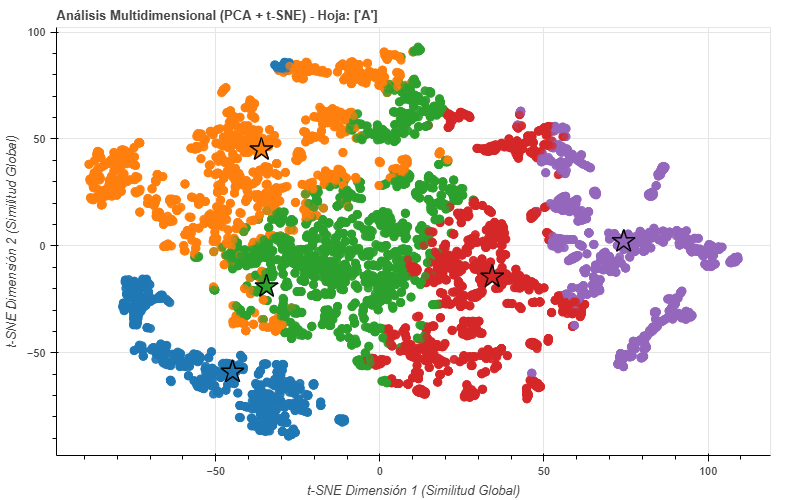